train shape: (250, 22)
test shape: (250, 22)

전처리 완료 — feature 수: 16
features: ['기권율_직전_pct', '청년_20대_투표율_pct', '장년_30-40대_투표율_pct', '중년_50-60대_투표율_pct', '고령_70대이상_투표율_pct', '세대격차_pct', '청년인구비율_pct', '장년인구비율_pct', '중년인구비율_pct', '고령인구비율_pct', '기권의향률_pct', '정치무관심률_pct', '효능감_평균', '정책인지_평균', '공정선거인식_평균', '시도_target_enc']
train/test feature 일치: True

Train: (200, 16) | Val: (50, 16) | Test: (250, 16)

>>> Lasso GridSearchCV <<<
  best alpha: {'lasso__alpha': 0.05}
  [Lasso] RMSE=1.2818 | MAE=1.0892 | R²=0.9836

>>> Ridge GridSearchCV <<<
  best alpha: {'ridge__alpha': 5.0}
  [Ridge] RMSE=1.3363 | MAE=1.1453 | R²=0.9822

>>> LightGBM RandomizedSearchCV (n_iter=60) <<<
  best params: {'lgbmregressor__subsample': 0.8, 'lgbmregressor__reg_lambda': 0.0, 'lgbmregressor__reg_alpha': 0.0, 'lgbmregressor__num_leaves': 31, 'lgbmregressor__n_estimators': 200, 'lgbmregressor__min_child_samples': 10, 'lgbmregressor__max_depth': 4, 'lgbmregressor__learning_rate': 0.05, 'lgbmregressor__colsample_bytree':

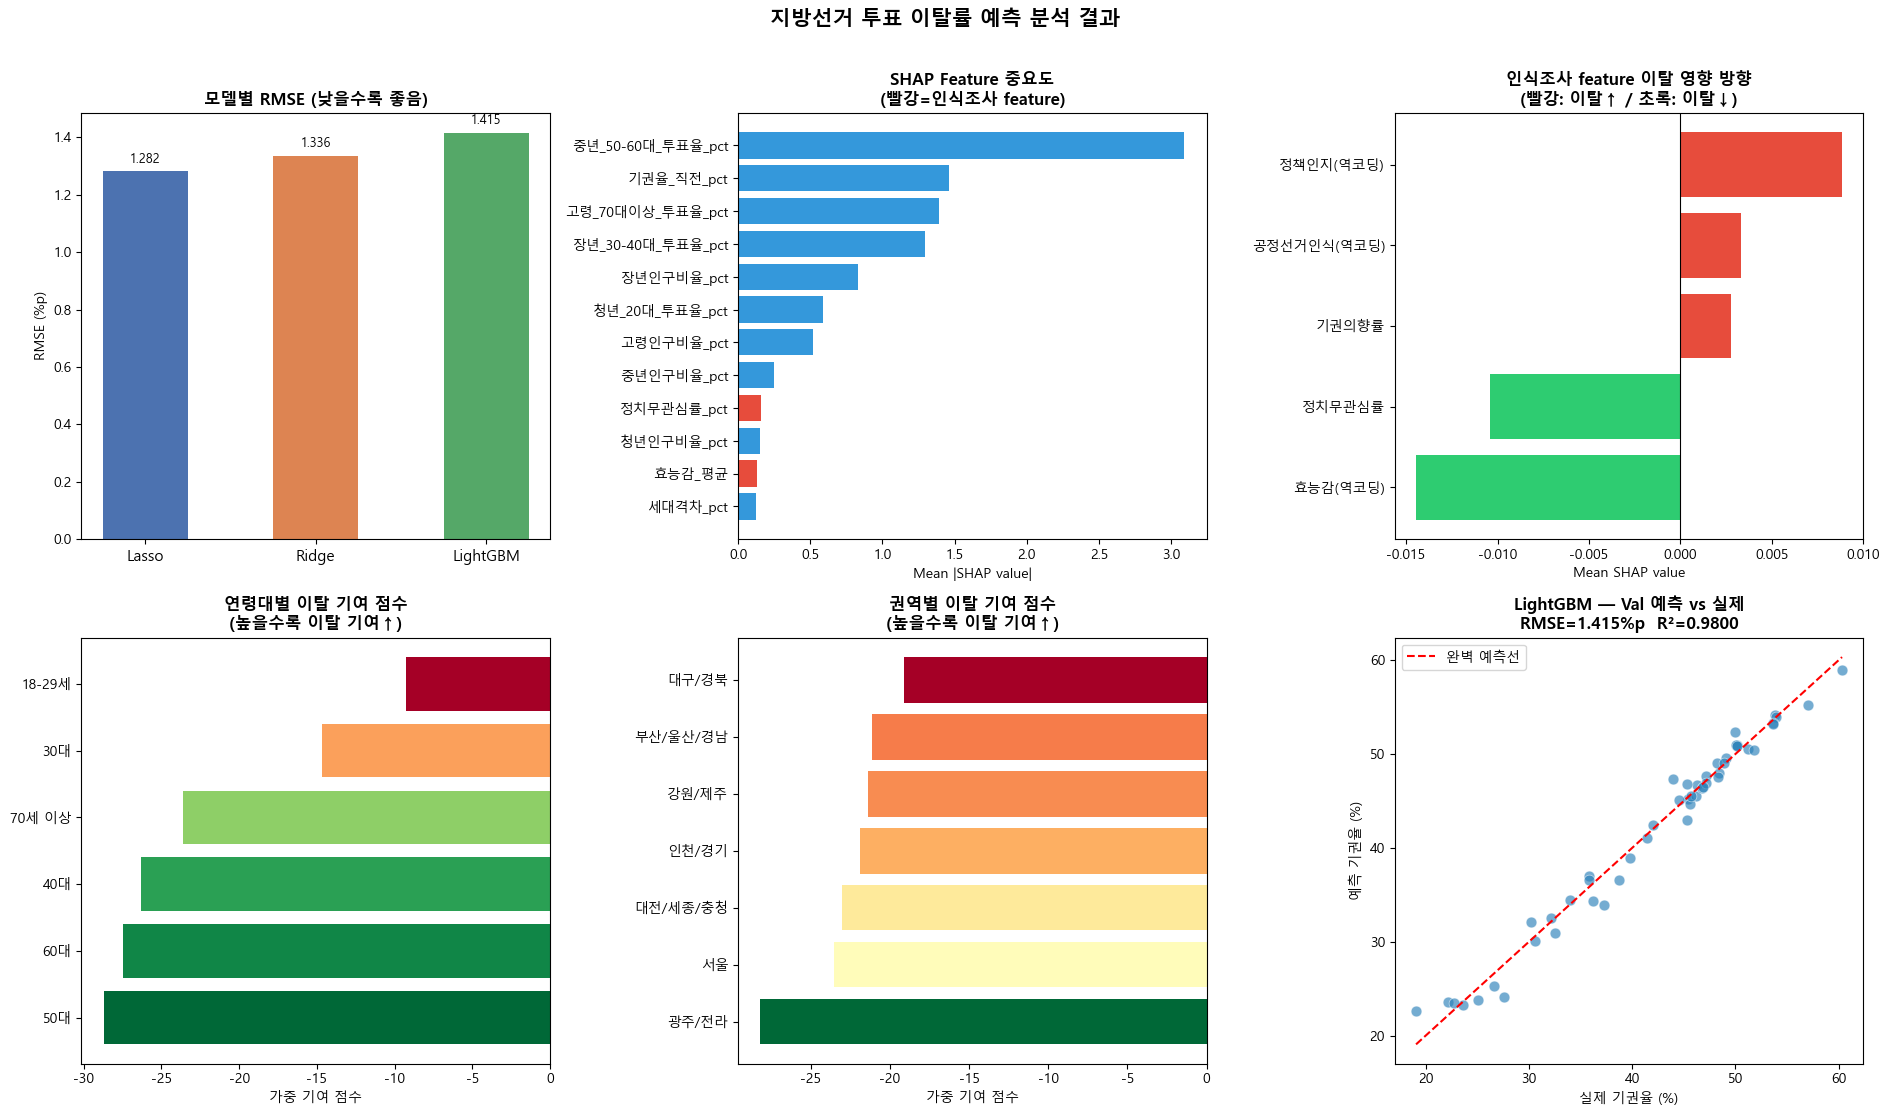

탐색용 시각화 저장 완료 → analysis_summary.png


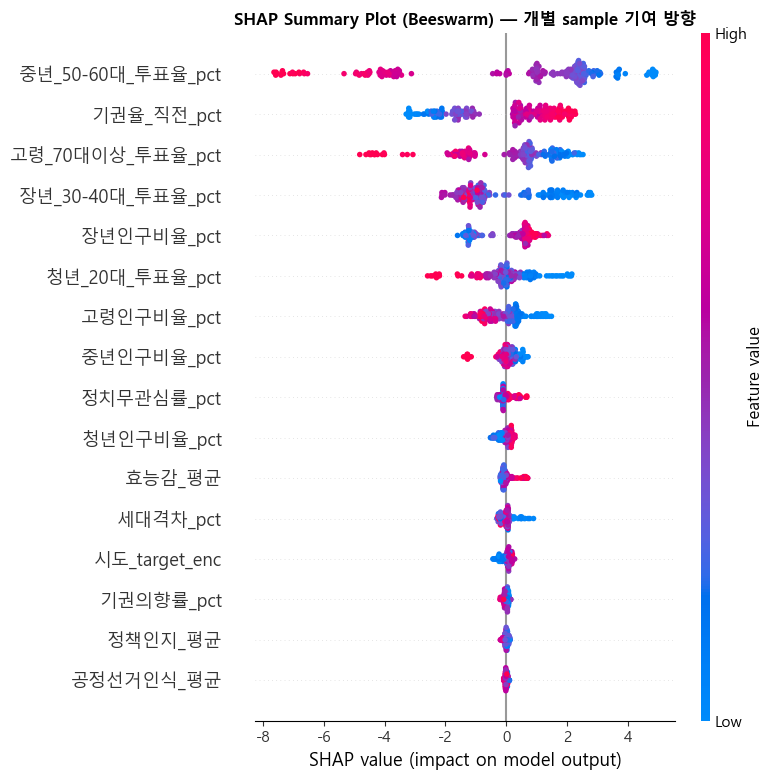

SHAP beeswarm 저장 완료 → shap_beeswarm.png


In [ ]:
# =============================================================================
# 지방선거 투표 이탈률 예측 ML 파이프라인 (누수 수정 버전)
#
# [데이터 구조]
#   train: 8회 지선 데이터
#     - Y (target)  : 기권율_이전회_pct  (= 8회 기권율)
#     - key feature : 기권율_전전회_pct  (= 7회 기권율) → "직전 기권율"로 rename
#   test:  9회 지선 예측용
#     - Y           : 9회 기권율 (미지, NaN)
#     - key feature : 기권율_이전회_pct  (= 8회 기권율) → "직전 기권율"로 rename
#
# [누수 제거]
#   기존 기권율_Y_pct == 기권율_이전회_pct 동일값 → 둘 다 feature에서 제거
#   기권율_증가_pct: train=8회-7회, test=0 → train/test 의미 불일치로 제거
#   투표율 계열: 기권율과 합=100 (선형 종속) → 제거
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import make_pipeline as pp
from sklearn.preprocessing import StandardScaler as std
from sklearn.model_selection import train_test_split as tts
from lightgbm import LGBMRegressor as lgbm
import shap

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 0. 데이터 로드

file_path = r"C:\SKN_2ND_PROJECT_1TEAM\SKN31-2nd-1Team\data\processed"

train      = pd.read_csv(f"{file_path}/train_total.csv")
test       = pd.read_csv(f"{file_path}/predict_9th.csv")
survey_raw = pd.read_csv(f"{file_path}/제9회유권자의식조사_v2.csv")

print("train shape:", train.shape)
print("test shape:", test.shape)


# 1. 전처리


# 1-1. 불필요 컬럼 제거

#   train: 기권율_이전회(=Y 자체), 투표율 계열(기권율과 종속), 증가_pct(test불일치), 구시군명
#   test:  추가로 전전회(=이전회와 동일값)도 제거

DROP_TRAIN = ['투표율_이전회_pct', 
              '투표율_전전회_pct',
              '기권율_Y_pct', 
              '기권율_증가_pct', 
              '구시군명']

DROP_TEST  = ['투표율_이전회_pct', 
              '투표율_전전회_pct',
              '기권율_Y_pct', 
              '기권율_증가_pct', 
              '구시군명',
              '기권율_전전회_pct']   # test에서 전전회=이전회 동일값이므로 제거

train_df = train.drop(columns=DROP_TRAIN).copy()
test_df  = test.drop(columns=DROP_TEST).copy()

# 1-2. Y 분리 (train)
y_all = train_df.pop('기권율_이전회_pct')

# 1-3. 컬럼명 통일 ("직전 선거 기권율" 개념으로 rename)

#  train 기권율_전전회_pct(7회) == test 기권율_이전회_pct(8회) → 같은 역할
train_df = train_df.rename(columns={'기권율_전전회_pct': '기권율_직전_pct'})
test_df  = test_df.rename(columns={'기권율_이전회_pct':  '기권율_직전_pct'})

# 1-4. 역코딩: "높을수록 이탈 가능성↑" 방향 통일

#   효능감    : 높을수록 긍정 → 역코딩
#   정책인지   : 낮을수록 잘 앎(긍정) → 역코딩
#   공정선거인식: 낮을수록 공정(긍정) → 역코딩

REVERSE_COLS = ['효능감_평균', '정책인지_평균', '공정선거인식_평균']
for col in REVERSE_COLS:
    train_df[col] = train_df[col] * -1
    test_df[col]  = test_df[col]  * -1

# 1-5. Target Encoding (시도명 → train Y 평균, leakage 방지)

sido_mean = y_all.groupby(train_df['시도명']).mean().rename('시도_target_enc')
train_df  = train_df.join(sido_mean, on='시도명').drop(columns=['시도명'])
test_df   = test_df.join(sido_mean,  on='시도명').drop(columns=['시도명'])

FEATURE_COLS = train_df.columns.tolist()
print(f"\n전처리 완료 — feature 수: {len(FEATURE_COLS)}")
print("features:", FEATURE_COLS)
print("train/test feature 일치:", sorted(train_df.columns.tolist()) == sorted(test_df.columns.tolist()))


# 2. Train / Validation Split

X_train, X_val, y_train, y_val = tts(train_df, y_all, test_size=0.2, random_state=42)
X_test = test_df[FEATURE_COLS]

print(f"\nTrain: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")


# 3. 모델 파이프라인 & 하이퍼파라미터 탐색

def evaluate(name, model, Xv, yv):
    pred = model.predict(Xv)
    rmse = np.sqrt(mean_squared_error(yv, pred))
    mae  = mean_absolute_error(yv, pred)
    r2   = r2_score(yv, pred)
    print(f"  [{name}] RMSE={rmse:.4f} | MAE={mae:.4f} | R²={r2:.4f}")
    return pred, {'model': name, 'RMSE': round(rmse,4), 'MAE': round(mae,4), 'R2': round(r2,4)}

# 3-1. Lasso (GridSearchCV)
print("\n>>> Lasso GridSearchCV <<<")

gs_lasso = GridSearchCV(
    pp(std(), Lasso(max_iter=10000)),
    {'lasso__alpha': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0]},
    cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

gs_lasso.fit(X_train, y_train)

print(f"  best alpha: {gs_lasso.best_params_}")

pred_lasso, m_lasso = evaluate('Lasso', gs_lasso, X_val, y_val)

# 3-2. Ridge (GridSearchCV)
print("\n>>> Ridge GridSearchCV <<<")

gs_ridge = GridSearchCV(
    pp(std(), Ridge()),
    {'ridge__alpha': [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0]},
    cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

gs_ridge.fit(X_train, y_train)

print(f"  best alpha: {gs_ridge.best_params_}")

pred_ridge, m_ridge = evaluate('Ridge', gs_ridge, X_val, y_val)

# 3-3. LightGBM (RandomizedSearchCV)
print("\n>>> LightGBM RandomizedSearchCV (n_iter=60) <<<")
lgbm_params = {
    'lgbmregressor__n_estimators'    : [100, 200, 300, 500],
    'lgbmregressor__learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'lgbmregressor__max_depth'       : [3, 4, 5, 6, -1],
    'lgbmregressor__num_leaves'      : [15, 31, 63],
    'lgbmregressor__min_child_samples': [5, 10, 20],
    'lgbmregressor__subsample'       : [0.6, 0.8, 1.0],
    'lgbmregressor__colsample_bytree': [0.6, 0.8, 1.0],
    'lgbmregressor__reg_alpha'       : [0.0, 0.1, 0.5],
    'lgbmregressor__reg_lambda'      : [0.0, 0.1, 1.0],
}

rs_lgbm = RandomizedSearchCV(
    pp(std(), lgbm(random_state=42, verbose=-1)),
    lgbm_params, n_iter=60, cv=5,
    scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)

rs_lgbm.fit(X_train, y_train)

print(f"  best params: {rs_lgbm.best_params_}")

pred_lgbm, m_lgbm = evaluate('LightGBM', rs_lgbm, X_val, y_val)

# 3-4. 성능 비교

metrics_all = [m_lasso, m_ridge, m_lgbm]
metrics_df  = pd.DataFrame(metrics_all).set_index('model')
print("\n=== 모델 성능 비교 ===")
print(metrics_df)


# 4. SHAP Feature Importance (LightGBM)

best_lgbm_m = rs_lgbm.best_estimator_.named_steps['lgbmregressor']
scaler_m    = rs_lgbm.best_estimator_.named_steps['standardscaler']
X_train_sc  = scaler_m.transform(X_train)

explainer = shap.TreeExplainer(best_lgbm_m)
shap_vals = explainer.shap_values(X_train_sc)

shap_df = pd.DataFrame({
    'feature'   : FEATURE_COLS,
    'importance': np.abs(shap_vals).mean(axis=0),  # 중요도 크기
    'direction' : shap_vals.mean(axis=0)            # 양수=이탈↑, 음수=이탈↓
}).sort_values('importance', ascending=False).reset_index(drop=True)

shap_df['rank'] = shap_df.index + 1

print("\n=== SHAP Feature 중요도 순위 ===")
print(shap_df[['rank','feature','importance','direction']].to_string(index=False))


# 5. 인식조사 연령대 × 권역별 기여도 분석

SURVEY_FEATURES = ['기권의향률_pct','정치무관심률_pct','효능감_평균','정책인지_평균','공정선거인식_평균']

# 역코딩 (train과 동일 방향)
survey_raw[['효능감_평균','정책인지_평균','공정선거인식_평균']] *= -1

# 인식조사 feature SHAP 가중치 (정규화)
s_shap = shap_df[shap_df['feature'].isin(SURVEY_FEATURES)].copy()
s_shap['weight'] = s_shap['importance'] / s_shap['importance'].sum()
weight_map = dict(zip(s_shap['feature'], s_shap['weight']))

print("\n=== 인식조사 feature SHAP 가중치 (정규화) ===")
print(s_shap[['feature','importance','weight']].to_string(index=False))

def weighted_score(row, wm, feats):
    """각 인식조사 feature × SHAP 가중치 → 이탈 기여 점수"""
    return sum(row[f] * wm.get(f, 0) for f in feats)

# 연령대별
age_df = survey_raw[survey_raw['집단구분']=='연령별'].copy()
age_df = age_df[age_df['세부집단']!='전체']
age_df['이탈기여점수'] = age_df.apply(weighted_score, wm=weight_map, feats=SURVEY_FEATURES, axis=1)
age_df = age_df.sort_values('이탈기여점수', ascending=False).reset_index(drop=True)
age_df['순위'] = age_df.index + 1

# 권역별
region_df = survey_raw[survey_raw['집단구분']=='권역별'].copy()
region_df['이탈기여점수'] = region_df.apply(weighted_score, wm=weight_map, feats=SURVEY_FEATURES, axis=1)
region_df = region_df.sort_values('이탈기여점수', ascending=False).reset_index(drop=True)
region_df['순위'] = region_df.index + 1

print("\n=== 연령대별 이탈 기여도 순위 ===")
print(age_df[['순위','세부집단','이탈기여점수']].to_string(index=False))
print("\n=== 권역별 이탈 기여도 순위 ===")
print(region_df[['순위','세부집단','이탈기여점수']].to_string(index=False))


# 6. 9회 지선 Test 예측

test_pred   = rs_lgbm.predict(X_test)
test_result = pd.read_csv(f"{file_path}/predict_9th_v3.csv")
test_result['예측_기권율_pct'] = test_pred.round(2)
test_result.to_csv(f"{file_path}/prediction_9th_result.csv", index=False, encoding='utf-8-sig')

print("\n=== 9회 예측 샘플 (8회 대비 변화) ===")
sample = test_result[['시도명','구시군명','기권율_이전회_pct','예측_기권율_pct']].head(15).copy()
sample['변화_pct'] = (sample['예측_기권율_pct'] - sample['기권율_이전회_pct']).round(2)
print(sample.to_string(index=False))



#<===================================================================================
# 위는 ML / 밑은 팀 내부 확인용으로 시각화 plot 만드는 코드들입니다.
#===================================================================================>



# 7. 탐색용 시각화 (팀 내부 확인용)

SURVEY_FEATURES_LABEL = {
    '기권의향률_pct': '기권의향률',
    '정치무관심률_pct': '정치무관심률',
    '효능감_평균': '효능감(역코딩)',
    '정책인지_평균': '정책인지(역코딩)',
    '공정선거인식_평균': '공정선거인식(역코딩)'
}

fig, axes = plt.subplots(2, 3, figsize=(19, 11))
fig.suptitle("지방선거 투표 이탈률 예측 분석 결과", fontsize=15, fontweight='bold', y=1.01)

# 7-1. 모델 성능 비교 =====================================================================================

ax = axes[0, 0]

x  = np.arange(len(metrics_df))

bars = ax.bar(x, metrics_df['RMSE'], color=['#4C72B0','#DD8452','#55A868'], width=0.5)

ax.set_xticks(x); ax.set_xticklabels(metrics_df.index, fontsize=11)

ax.set_title("모델별 RMSE (낮을수록 좋음)", fontweight='bold')

ax.set_ylabel("RMSE (%p)")

for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

# 7-2. SHAP Feature 중요도 전체 ============================================================================

ax = axes[0, 1]

plot_df = shap_df.head(12).sort_values('importance')

colors  = ['#e74c3c' if f in SURVEY_FEATURES else '#3498db' for f in plot_df['feature']]

ax.barh(plot_df['feature'], plot_df['importance'], color=colors)

ax.set_title("SHAP Feature 중요도\n(빨강=인식조사 feature)", fontweight='bold')

ax.set_xlabel("Mean |SHAP value|")

# 7-3. 인식조사 feature 방향성 (이탈에 미치는 방향) ======================================================

ax = axes[0, 2]

sf = shap_df[shap_df['feature'].isin(SURVEY_FEATURES)].copy()

sf['label'] = sf['feature'].map(SURVEY_FEATURES_LABEL)

sf = sf.sort_values('direction')

colors_dir = ['#2ecc71' if v < 0 else '#e74c3c' for v in sf['direction']]

ax.barh(sf['label'], sf['direction'], color=colors_dir)

ax.axvline(0, color='black', linewidth=0.8)

ax.set_title("인식조사 feature 이탈 영향 방향\n(빨강: 이탈↑ / 초록: 이탈↓)", fontweight='bold')

ax.set_xlabel("Mean SHAP value")

# 7-4. 연령대별 이탈 기여점수 ==============================================================================

ax = axes[1, 0]

age_plot = age_df[age_df['세부집단']!='전체'].sort_values('이탈기여점수')

norm = plt.Normalize(age_plot['이탈기여점수'].min(), age_plot['이탈기여점수'].max())

cmap = plt.cm.RdYlGn_r

colors_age = [cmap(norm(v)) for v in age_plot['이탈기여점수']]

ax.barh(age_plot['세부집단'], age_plot['이탈기여점수'], color=colors_age)

ax.set_title("연령대별 이탈 기여 점수\n(높을수록 이탈 기여↑)", fontweight='bold')

ax.set_xlabel("가중 기여 점수")

# 7-5. 권역별 이탈 기여점수 ================================================================================

ax = axes[1, 1]

region_plot = region_df.sort_values('이탈기여점수')

norm_r = plt.Normalize(region_plot['이탈기여점수'].min(), region_plot['이탈기여점수'].max())

colors_reg = [cmap(norm_r(v)) for v in region_plot['이탈기여점수']]

ax.barh(region_plot['세부집단'], region_plot['이탈기여점수'], color=colors_reg)

ax.set_title("권역별 이탈 기여 점수\n(높을수록 이탈 기여↑)", fontweight='bold')

ax.set_xlabel("가중 기여 점수")

# 7-6. Val 예측 vs 실제 ===================================================================================

ax = axes[1, 2]

ax.scatter(y_val, pred_lgbm, alpha=0.65, color='#2980B9', edgecolors='white', linewidths=0.5, s=60)

mn, mx = float(y_val.min()), float(y_val.max())

ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='완벽 예측선')

ax.set_title(f"LightGBM — Val 예측 vs 실제\nRMSE={m_lgbm['RMSE']:.3f}%p  R²={m_lgbm['R2']:.4f}",
             fontweight='bold')

ax.set_xlabel("실제 기권율 (%)"); ax.set_ylabel("예측 기권율 (%)")

ax.legend()

plt.tight_layout()
plt.savefig(f"{file_path}/analysis_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("탐색용 시각화 저장 완료 → analysis_summary.png")

# 7-7. SHAP Beeswarm (개별 sample 방향성)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_train_sc, feature_names=FEATURE_COLS, show=False)
plt.title("SHAP Summary Plot (Beeswarm) — 개별 sample 기여 방향", fontweight='bold')
plt.tight_layout()
plt.savefig(f"{file_path}/shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()
print("SHAP beeswarm 저장 완료 → shap_beeswarm.png")